# Alpha Iteration: Finding Diversifying Factors

**Context**: The BBIBOLL factor from `alpha_research.ipynb` showed weak but significant
mean-reversion (IC = −0.022, t = −2.30 at 5d). Momentum 20d was not significant and
their combination *diluted* the signal because both had negative IC.

**Goal**: Build 3 new factors with **distinct economic mechanisms**, evaluate each,
then find a **genuinely diversifying combination** where composite IR > max(individual IR).

---

## Research Protocol (per PERSONA.md)

For each factor:
1. **Hypothesis** — What economic mechanism should make this work?
2. **Assumptions** — What market conditions does it require?
3. **Implementation** — Build the signal
4. **Statistical validation** — IC, IR, t-stat, IC decay, turnover
5. **Robustness** — Is it stable across time? Regime-dependent?
6. **Failure analysis** — Under what conditions does it break?

---

## Factor Design

| # | Factor | Type | Mechanism |
|---|--------|------|-----------|
| 1 | Short-term reversal (5d) | Mean-reversion | Overreaction / liquidity provision |
| 2 | Volume-price divergence | Trend-following | Informed trading confirmation |
| 3 | Realized vol ratio | Risk-based | Volatility regime detection |
| 4 | BBIBOLL (from prior notebook) | Mean-reversion | Multi-MA deviation |

## 0. Setup

In [2]:
import sys
from pathlib import Path

# Add src/ to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Clear cached project modules (pick up any edits to src/)
for mod_name in list(sys.modules.keys()):
    if any(mod_name.startswith(p) for p in ("config", "data.", "strategy.", "alpha.", "backtest.", "utils.")):
        del sys.modules[mod_name]

print(f"Project root: {PROJECT_ROOT}")
print(f"src/ added to path: {SRC_DIR}")

Project root: /home/jerryhong/code-projects/quant101
src/ added to path: /home/jerryhong/code-projects/quant101/src


In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from data.universe import get_universe
from data.loader.data_loader import stock_load_process
from indicators.registry import get_indicator
from indicators.bbiboll_indicator import calculate_bbiboll  # noqa: F401
from alpha.forward_returns import compute_forward_returns
from alpha.factor_analyzer import FactorAnalyzer
from alpha.preprocessing import preprocess_factor
from alpha.combination import combine_factors

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

HORIZONS = [1, 2, 5, 10, 20]

print("Imports OK ✅")

Imports OK ✅


## 1. Load Data

Same universe as `alpha_research.ipynb` — ~50 liquid large-cap US stocks, 2 years.

In [4]:
UNIVERSE = get_universe("US_LARGE_CAP_50")
START_DATE = "2023-01-01"
END_DATE = "2026-02-28"

ohlcv = stock_load_process(
    tickers=UNIVERSE,
    start_date=START_DATE,
    end_date=END_DATE,
    timeframe="1d",
    use_cache=True,
    skip_low_volume=False,
).collect()

print(f"Shape: {ohlcv.shape}")
print(f"Tickers loaded: {ohlcv['ticker'].n_unique()}")
print(f"Date range: {ohlcv['timestamps'].min()} → {ohlcv['timestamps'].max()}")

# Compute forward returns once — shared across all factors
returns_df = compute_forward_returns(ohlcv, horizons=HORIZONS)
print(f"\nForward returns: {returns_df.shape}")
print(f"Columns: {returns_df.columns}")

Loading from cache: /mnt/blackdisk/quant_data/polygon_data/processed/us_stocks_sip/day_aggs_v1/cache_c5e11349e9e04e8bdef2634ae48ac375.parquet
Cache loaded: 40,301 rows, 2.58 MB
Shape: (40301, 10)
Tickers loaded: 52
Date range: 2023-01-03 00:00:00-05:00 → 2026-02-26 00:00:00-05:00

Forward returns: (40301, 7)
Columns: ['date', 'ticker', 'forward_return_1d', 'forward_return_2d', 'forward_return_5d', 'forward_return_10d', 'forward_return_20d']


---

## 2. Factor 1: Short-Term Reversal (5d)

### Hypothesis
Stocks that dropped over the past 5 trading days will **outperform** over the next 5–10 days.

### Economic mechanism
- **Overreaction**: Noise traders push prices beyond fair value; informed traders pull them back.
- **Liquidity provision**: Market makers who absorb selling pressure earn a reversal premium.
- **Empirical basis**: Jegadeesh (1990) documented 1-week reversal in US equities. This is one of the most replicated anomalies.

### Assumptions
- Works best in **liquid, large-cap** stocks where mean-reversion is not arbitraged away instantly.
- May **fail in momentum regimes** (strong trends where reversals are punished).
- Requires low transaction costs relative to the reversal magnitude.

### Signal
$$\text{STR}_t = -r_{t-5:t} = -\frac{P_t - P_{t-5}}{P_{t-5}}$$
Negative sign: past losers get high signal (expected to bounce).

In [5]:
# Factor 1: Short-term reversal = negative 5-day return
str_df = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (-(pl.col("close") / pl.col("close").shift(5).over("ticker") - 1)).alias("value")
    )
    .filter(pl.col("value").is_not_null() & pl.col("value").is_finite())
    .select([
        pl.col("timestamps").alias("date"),
        pl.col("ticker"),
        pl.col("value"),
    ])
)

# Preprocess
str_clean = preprocess_factor(str_df, winsorize_pct=0.01, method="zscore", neutralize=[])

str_analyzer = FactorAnalyzer(str_clean, returns_df, min_observations=30)

print("=" * 60)
print("FACTOR 1: SHORT-TERM REVERSAL (5d)")
print("=" * 60)
str_summary = str_analyzer.summary(horizon=5)

print("\nIC Decay:")
str_decay = str_analyzer.ic_decay(horizons=HORIZONS)
print(str_decay)

FACTOR 1: SHORT-TERM REVERSAL (5d)

Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0088
  Std IC:           0.2300
  IR:              -0.0383
  t-stat:          -1.0694
  Hit Rate:          49.1%
  # Dates:             780
  Mean Turnover:    0.2876
  ⚠️  Not significant (|t| = 1.07 < 2)
  ⚠️  Weak factor (|IR| = 0.04 < 0.3)


IC Decay:
shape: (5, 5)
┌─────────┬───────────┬──────────┬───────────┬───────────┐
│ horizon ┆ mean_ic   ┆ std_ic   ┆ ir        ┆ t_stat    │
│ ---     ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ i64     ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
╞═════════╪═══════════╪══════════╪═══════════╪═══════════╡
│ 1       ┆ 0.000648  ┆ 0.249521 ┆ 0.002597  ┆ 0.072705  │
│ 2       ┆ -0.00164  ┆ 0.23987  ┆ -0.006836 ┆ -0.191275 │
│ 5       ┆ -0.008809 ┆ 0.230041 ┆ -0.038291 ┆ -1.069415 │
│ 10      ┆ 0.003013  ┆ 0.243201 ┆ 0.012389  ┆ 0.344905  │
│ 20      ┆ 0.004425  ┆ 0.23408  ┆ 0.018905  ┆ 0.522875  │
└─────────┴───────────┴──────────┴─────────

---

## 3. Factor 2: Volume-Price Divergence

### Hypothesis
When a stock rises on **abnormally high volume**, informed traders are accumulating —
the move should **continue**. When it rises on low volume, there's no conviction —
the move should **fade**.

### Economic mechanism
- **Information asymmetry**: Large informed orders create both price impact and volume spikes.
- **Attention**: High volume events attract trend followers, creating short-term momentum.
- **Volume confirms price**: A classic technical analysis principle, but here we test it statistically.

### Assumptions
- Volume is a **proxy for information arrival**, not just noise.
- Requires that **informed trading** moves volume meaningfully vs. the baseline.
- May fail when volume spikes are driven by **index rebalancing** (noise, not information).

### Signal
$$\text{VPD}_t = \frac{V_t}{\text{MA}_{20}(V)} \times \text{sign}(r_t)$$

- Volume ratio > 1 on up days → positive (buying conviction)
- Volume ratio > 1 on down days → negative (selling conviction)
- This is a **direction-aware** factor — should produce **positive IC** (trend-following)

In [6]:
# Factor 2: Volume-Price Divergence
# VPD = (volume / 20d_avg_volume) * sign(daily_return)
vpd_df = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns([
        # Volume ratio: today's volume / 20-day trailing mean volume
        (
            pl.col("volume") / pl.col("volume").rolling_mean(window_size=20).over("ticker")
        ).alias("vol_ratio"),
        # Daily return sign
        (pl.col("close") / pl.col("close").shift(1).over("ticker") - 1).alias("daily_ret"),
    ])
    .with_columns(
        (pl.col("vol_ratio") * pl.col("daily_ret").sign()).alias("value")
    )
    .filter(
        pl.col("value").is_not_null()
        & pl.col("value").is_not_nan()
        & pl.col("value").is_finite()
    )
    .select([
        pl.col("timestamps").alias("date"),
        pl.col("ticker"),
        pl.col("value"),
    ])
)

# Preprocess
vpd_clean = preprocess_factor(vpd_df, winsorize_pct=0.01, method="zscore", neutralize=[])

vpd_analyzer = FactorAnalyzer(vpd_clean, returns_df, min_observations=30)

print("=" * 60)
print("FACTOR 2: VOLUME-PRICE DIVERGENCE")
print("=" * 60)
vpd_summary = vpd_analyzer.summary(horizon=5)

print("\nIC Decay:")
vpd_decay = vpd_analyzer.ic_decay(horizons=HORIZONS)
print(vpd_decay)

FACTOR 2: VOLUME-PRICE DIVERGENCE

Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0032
  Std IC:           0.1909
  IR:              -0.0169
  t-stat:          -0.4674
  Hit Rate:          47.1%
  # Dates:             766
  Mean Turnover:    0.6340
  ⚠️  Not significant (|t| = 0.47 < 2)
  ⚠️  Weak factor (|IR| = 0.02 < 0.3)


IC Decay:
shape: (5, 5)
┌─────────┬───────────┬──────────┬───────────┬──────────┐
│ horizon ┆ mean_ic   ┆ std_ic   ┆ ir        ┆ t_stat   │
│ ---     ┆ ---       ┆ ---      ┆ ---       ┆ ---      │
│ i64     ┆ f64       ┆ f64      ┆ f64       ┆ f64      │
╞═════════╪═══════════╪══════════╪═══════════╪══════════╡
│ 1       ┆ 0.00319   ┆ 0.19862  ┆ 0.016063  ┆ 0.444847 │
│ 2       ┆ 0.006846  ┆ 0.198714 ┆ 0.03445   ┆ 0.954073 │
│ 5       ┆ -0.003224 ┆ 0.190915 ┆ -0.016889 ┆ -0.46742 │
│ 10      ┆ 0.003077  ┆ 0.192815 ┆ 0.015958  ┆ 0.440214 │
│ 20      ┆ -0.008045 ┆ 0.185458 ┆ -0.043382 ┆ -1.18885 │
└─────────┴───────────┴──────────┴───────────┴────────

---

## 4. Factor 3: Realized Volatility Ratio

### Hypothesis
Stocks where **short-term volatility is rising relative to long-term volatility**
are entering a new regime. The direction of the effect is an empirical question:

- **Risk premium view**: Higher vol → higher expected return (compensation for risk)
- **Leverage effect view**: Higher vol → lower expected return (firms in distress)
- **Volatility clustering**: Vol ratio > 1 predicts continued elevated vol, not necessarily direction

### Economic mechanism
This is fundamentally a **regime detection** signal. It doesn't predict direction directly
but identifies stocks in transition. Its value in combination depends on being **orthogonal**
to price-based factors like reversal and BBIBOLL.

### Assumptions
- Realized vol is a reasonable proxy for future vol (vol clustering is well-documented).
- The 5d/20d ratio captures meaningful regime shifts, not just noise.
- May fail when **vol is driven by single events** (earnings, FDA) rather than persistent regime change.

### Signal
$$\text{VolRatio}_t = \frac{\sigma_{5d}(r)}{\sigma_{20d}(r)}$$

Where $\sigma_{Nd}(r)$ is the realized volatility (std of daily log returns) over the trailing N days.

In [7]:
# Factor 3: Realized Volatility Ratio = sigma_5d / sigma_20d
vol_df = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        # Daily log return
        (pl.col("close") / pl.col("close").shift(1).over("ticker")).log().alias("log_ret")
    )
    .with_columns([
        # 5-day realized vol (std of log returns)
        pl.col("log_ret").rolling_std(window_size=5).over("ticker").alias("vol_5d"),
        # 20-day realized vol
        pl.col("log_ret").rolling_std(window_size=20).over("ticker").alias("vol_20d"),
    ])
    .with_columns(
        (pl.col("vol_5d") / pl.col("vol_20d")).alias("value")
    )
    .filter(
        pl.col("value").is_not_null()
        & pl.col("value").is_not_nan()
        & pl.col("value").is_finite()
        & (pl.col("vol_20d") > 1e-8)  # avoid division by near-zero vol
    )
    .select([
        pl.col("timestamps").alias("date"),
        pl.col("ticker"),
        pl.col("value"),
    ])
)

# Preprocess
vol_clean = preprocess_factor(vol_df, winsorize_pct=0.01, method="zscore", neutralize=[])

vol_analyzer = FactorAnalyzer(vol_clean, returns_df, min_observations=30)

print("=" * 60)
print("FACTOR 3: REALIZED VOLATILITY RATIO (5d/20d)")
print("=" * 60)
vol_summary = vol_analyzer.summary(horizon=5)

print("\nIC Decay:")
vol_decay = vol_analyzer.ic_decay(horizons=HORIZONS)
print(vol_decay)

FACTOR 3: REALIZED VOLATILITY RATIO (5d/20d)

Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0143
  Std IC:           0.1678
  IR:              -0.0850
  t-stat:          -2.3510
  Hit Rate:          48.1%
  # Dates:             765
  Mean Turnover:    0.2896
  ✅ Statistically significant (|t| = 2.35 > 2)
  ⚠️  Weak factor (|IR| = 0.08 < 0.3)


IC Decay:
shape: (5, 5)
┌─────────┬───────────┬──────────┬───────────┬───────────┐
│ horizon ┆ mean_ic   ┆ std_ic   ┆ ir        ┆ t_stat    │
│ ---     ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ i64     ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
╞═════════╪═══════════╪══════════╪═══════════╪═══════════╡
│ 1       ┆ 0.001126  ┆ 0.170698 ┆ 0.006598  ┆ 0.182976  │
│ 2       ┆ -0.003665 ┆ 0.172188 ┆ -0.021286 ┆ -0.58989  │
│ 5       ┆ -0.014259 ┆ 0.167751 ┆ -0.085    ┆ -2.350971 │
│ 10      ┆ -0.009051 ┆ 0.163015 ┆ -0.055521 ┆ -1.530604 │
│ 20      ┆ -0.000272 ┆ 0.168223 ┆ -0.001618 ┆ -0.044304 │
└─────────┴───────────┴──

---

## 5. BBIBOLL Baseline (from prior notebook)

Rebuild the BBIBOLL factor here for direct comparison.

In [8]:
# BBIBOLL factor (baseline from alpha_research.ipynb)
bbiboll_fn = get_indicator("bbiboll")
ohlcv_bb = bbiboll_fn(ohlcv)

bbi_df = (
    ohlcv_bb
    .with_columns(
        ((pl.col("close") - pl.col("bbi")) / pl.col("dev")).alias("value"),
    )
    .filter(
        pl.col("value").is_not_null()
        & pl.col("value").is_not_nan()
        & pl.col("value").is_finite()
    )
    .select([
        pl.col("timestamps").alias("date"),
        pl.col("ticker"),
        pl.col("value"),
    ])
)

bbi_clean = preprocess_factor(bbi_df, winsorize_pct=0.01, method="zscore", neutralize=[])

bbi_analyzer = FactorAnalyzer(bbi_clean, returns_df, min_observations=30)

print("=" * 60)
print("BASELINE: BBIBOLL (from prior notebook)")
print("=" * 60)
bbi_summary = bbi_analyzer.summary(horizon=5)
bbi_decay = bbi_analyzer.ic_decay(horizons=HORIZONS)

BASELINE: BBIBOLL (from prior notebook)

Factor Evaluation Summary (horizon=5d)
  Mean IC:          0.0030
  Std IC:           0.2093
  IR:               0.0143
  t-stat:           0.3933
  Hit Rate:          50.8%
  # Dates:             752
  Mean Turnover:    0.3088
  ⚠️  Not significant (|t| = 0.39 < 2)
  ⚠️  Weak factor (|IR| = 0.01 < 0.3)



---

## 6. Factor Comparison Dashboard

Side-by-side comparison of all 4 factors on key metrics.

In [9]:
# --- Comparison table ---
all_summaries = {
    "BBIBOLL": bbi_summary,
    "STR (5d)": str_summary,
    "Vol-Price Div": vpd_summary,
    "Vol Ratio": vol_summary,
}

comparison = pl.DataFrame({
    "Factor": list(all_summaries.keys()),
    "Mean IC": [s["mean_ic"] for s in all_summaries.values()],
    "IC Std": [s["std_ic"] for s in all_summaries.values()],
    "IR": [s["ir"] for s in all_summaries.values()],
    "t-stat": [s["t_stat"] for s in all_summaries.values()],
    "Hit Rate %": [s["hit_rate"] for s in all_summaries.values()],
    "Turnover": [s["mean_turnover"] for s in all_summaries.values()],
})

print("\n📊 Factor Comparison (5d horizon):")
print(comparison)

# Significance check
print("\n🔬 Statistical significance (|t| > 2.0):")
for name, s in all_summaries.items():
    sig = "✅ SIGNIFICANT" if abs(s["t_stat"]) > 2.0 else "❌ NOT significant"
    print(f"  {name:15s}: t = {s['t_stat']:+.2f}  →  {sig}")


📊 Factor Comparison (5d horizon):
shape: (4, 7)
┌───────────────┬───────────┬──────────┬───────────┬───────────┬────────────┬──────────┐
│ Factor        ┆ Mean IC   ┆ IC Std   ┆ IR        ┆ t-stat    ┆ Hit Rate % ┆ Turnover │
│ ---           ┆ ---       ┆ ---      ┆ ---       ┆ ---       ┆ ---        ┆ ---      │
│ str           ┆ f64       ┆ f64      ┆ f64       ┆ f64       ┆ f64        ┆ f64      │
╞═══════════════╪═══════════╪══════════╪═══════════╪═══════════╪════════════╪══════════╡
│ BBIBOLL       ┆ 0.003003  ┆ 0.209337 ┆ 0.014344  ┆ 0.393339  ┆ 50.797872  ┆ 0.308845 │
│ STR (5d)      ┆ -0.008809 ┆ 0.230041 ┆ -0.038291 ┆ -1.069415 ┆ 49.102564  ┆ 0.287642 │
│ Vol-Price Div ┆ -0.003224 ┆ 0.190915 ┆ -0.016889 ┆ -0.46742  ┆ 47.127937  ┆ 0.633959 │
│ Vol Ratio     ┆ -0.014259 ┆ 0.167751 ┆ -0.085    ┆ -2.350971 ┆ 48.104575  ┆ 0.289644 │
└───────────────┴───────────┴──────────┴───────────┴───────────┴────────────┴──────────┘

🔬 Statistical significance (|t| > 2.0):
  BBIBOLL        : t

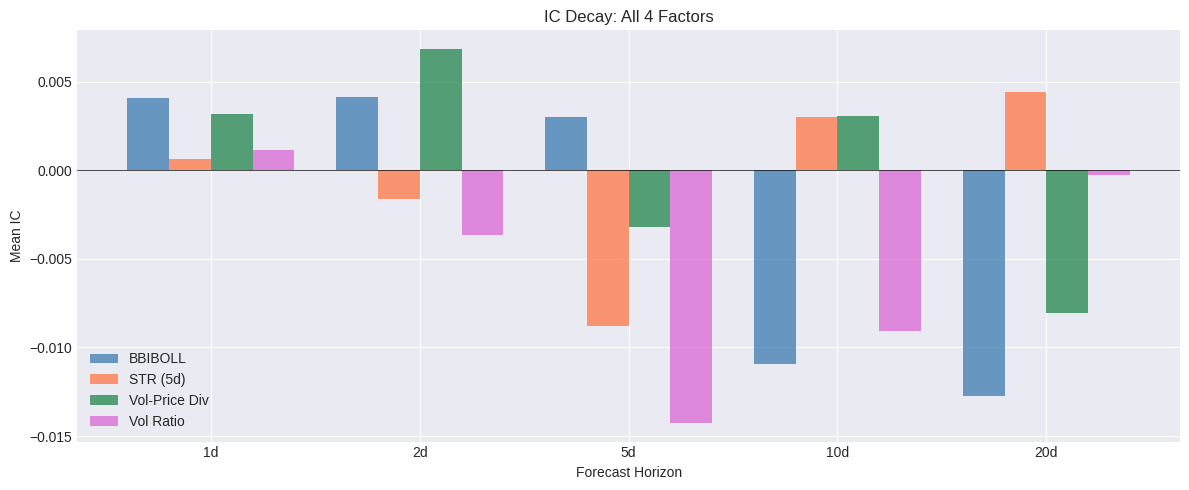

In [10]:
# --- IC Decay comparison chart ---
fig, ax = plt.subplots(figsize=(12, 5))

all_decays = {
    "BBIBOLL": bbi_decay,
    "STR (5d)": str_decay,
    "Vol-Price Div": vpd_decay,
    "Vol Ratio": vol_decay,
}
colors = ["steelblue", "coral", "seagreen", "orchid"]
x = np.arange(len(HORIZONS))
width = 0.2

for i, (name, decay) in enumerate(all_decays.items()):
    offset = (i - 1.5) * width
    ax.bar(x + offset, decay["mean_ic"].to_list(), width,
           label=name, alpha=0.8, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("IC Decay: All 4 Factors")
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Mean IC")
ax.legend()
plt.tight_layout()
plt.show()

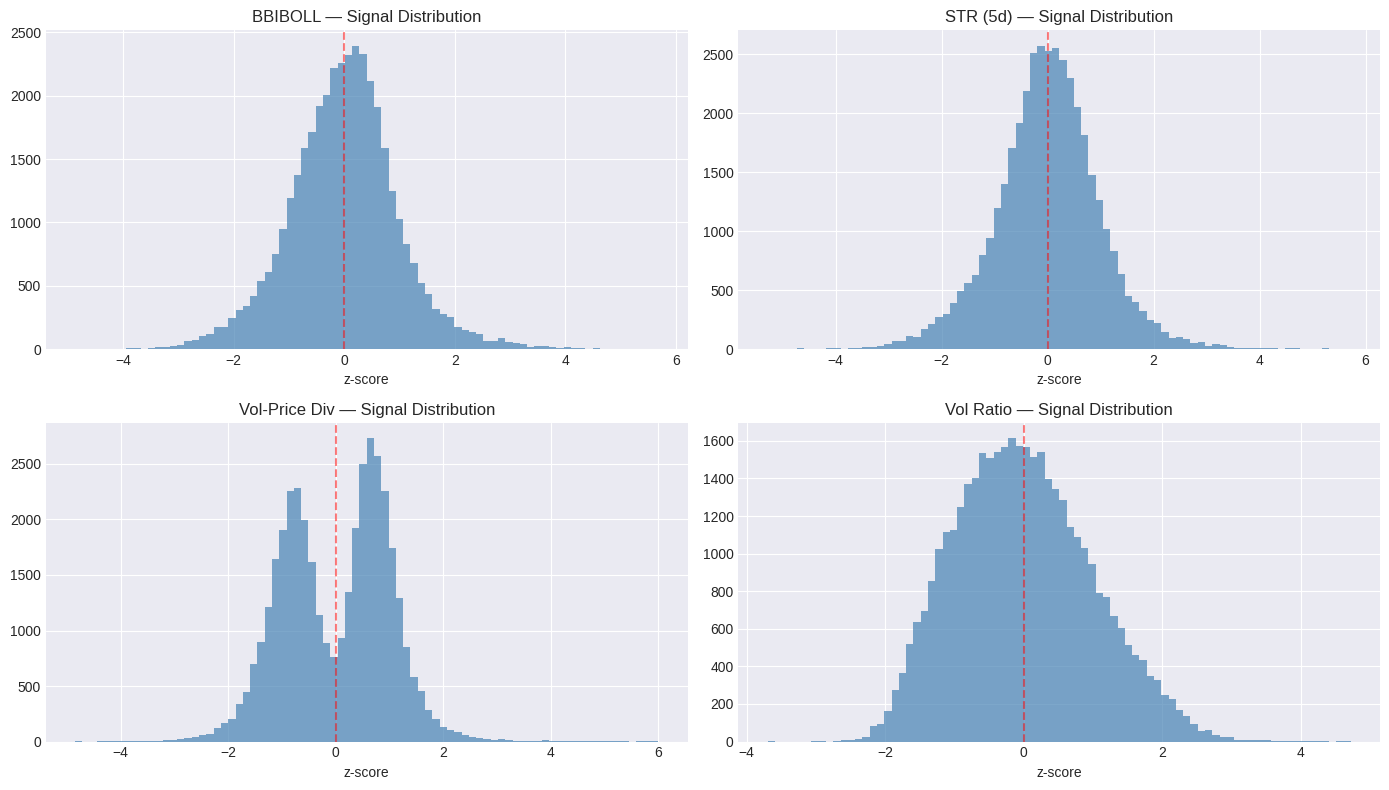

In [11]:
# --- Signal distribution comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

factor_data = {
    "BBIBOLL": bbi_clean,
    "STR (5d)": str_clean,
    "Vol-Price Div": vpd_clean,
    "Vol Ratio": vol_clean,
}

for ax, (name, df) in zip(axes.flat, factor_data.items()):
    vals = df["value"].to_numpy()
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins=80, edgecolor="none", alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", alpha=0.5)
    ax.set_title(f"{name} — Signal Distribution")
    ax.set_xlabel("z-score")

plt.tight_layout()
plt.show()

---

## 7. IC Correlation Matrix

Before combining factors, check their **IC correlation**.
Diversification only works if factors are imperfectly correlated.

- If IC correlation ≈ 1.0 → redundant, combination won't help (this is what happened with BBIBOLL + Momentum).
- If IC correlation ≈ 0 → orthogonal, combination will improve IR.
- If IC correlation < 0 → anti-correlated, combination will *strongly* improve IR.

📊 IC Correlation Matrix (5d horizon):
                       BBIBOLL       STR (5d)  Vol-Price Div      Vol Ratio
BBIBOLL                  1.000         -0.811          0.524          0.011
STR (5d)                -0.811          1.000         -0.395         -0.010
Vol-Price Div            0.524         -0.395          1.000         -0.024
Vol Ratio                0.011         -0.010         -0.024          1.000


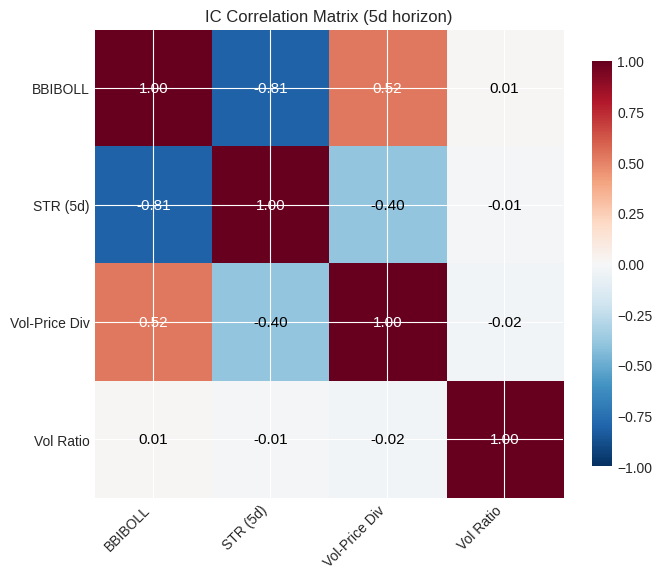

In [12]:
# Compute IC series for each factor, then correlate
ic_series_all = {}
analyzers = {
    "BBIBOLL": bbi_analyzer,
    "STR (5d)": str_analyzer,
    "Vol-Price Div": vpd_analyzer,
    "Vol Ratio": vol_analyzer,
}

for name, a in analyzers.items():
    ic_series_all[name] = a.ic_series(horizon=5).rename({"ic": name})

# Join all IC series on date
ic_merged = ic_series_all["BBIBOLL"]
for name in ["STR (5d)", "Vol-Price Div", "Vol Ratio"]:
    ic_merged = ic_merged.join(ic_series_all[name], on="date", how="inner")

# Correlation matrix
factor_names = ["BBIBOLL", "STR (5d)", "Vol-Price Div", "Vol Ratio"]
ic_np = ic_merged.select(factor_names).to_numpy()
corr_matrix = np.corrcoef(ic_np.T)

print("📊 IC Correlation Matrix (5d horizon):")
print(f"{'':15s}", end="")
for n in factor_names:
    print(f"{n:>15s}", end="")
print()
for i, n in enumerate(factor_names):
    print(f"{n:15s}", end="")
    for j in range(len(factor_names)):
        print(f"{corr_matrix[i,j]:>15.3f}", end="")
    print()

# Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(factor_names)))
ax.set_yticks(range(len(factor_names)))
ax.set_xticklabels(factor_names, rotation=45, ha="right")
ax.set_yticklabels(factor_names)

# Annotate
for i in range(len(factor_names)):
    for j in range(len(factor_names)):
        ax.text(j, i, f"{corr_matrix[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_matrix[i,j]) > 0.5 else "black", fontsize=11)

ax.set_title("IC Correlation Matrix (5d horizon)")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---

## 8. Multi-Factor Combination Experiment

The critical test: **does combining these factors produce a higher IR than any individual factor?**

We test multiple combination strategies:
1. **All 4 factors** — equal-weight
2. **Best pair** — the two factors with lowest IC correlation
3. **Significant-only** — only factors with |t| > 2
4. **IC-weighted** — weight ∝ historical mean |IC|

In [13]:
# --- Combination experiments ---
all_factors_clean = {
    "BBIBOLL": bbi_clean,
    "STR (5d)": str_clean,
    "Vol-Price Div": vpd_clean,
    "Vol Ratio": vol_clean,
}
all_ic_series = {name: analyzers[name].ic_series(horizon=5) for name in factor_names}

combo_results = {}

# 1. All 4 factors — Equal Weight
combo_all_ew = combine_factors(
    factors=list(all_factors_clean.values()),
    method="equal_weight",
)
combo_all_analyzer = FactorAnalyzer(combo_all_ew, returns_df, min_observations=30)
print("=" * 60)
print("COMBO 1: All 4 Factors — Equal Weight")
print("=" * 60)
combo_results["All 4 (EW)"] = combo_all_analyzer.summary(horizon=5)

# 2. IC-weighted (all 4 factors)
combo_all_icw = combine_factors(
    factors=list(all_factors_clean.values()),
    method="ic_weight",
    ic_series_list=list(all_ic_series.values()),
)
combo_icw_analyzer = FactorAnalyzer(combo_all_icw, returns_df, min_observations=30)
print("\n" + "=" * 60)
print("COMBO 2: All 4 Factors — IC-Weighted")
print("=" * 60)
combo_results["All 4 (IC-wt)"] = combo_icw_analyzer.summary(horizon=5)

COMBO 1: All 4 Factors — Equal Weight

Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0051
  Std IC:           0.1798
  IR:              -0.0282
  t-stat:          -0.7736
  Hit Rate:          46.8%
  # Dates:             752
  Mean Turnover:    0.5080
  ⚠️  Not significant (|t| = 0.77 < 2)
  ⚠️  Weak factor (|IR| = 0.03 < 0.3)


COMBO 2: All 4 Factors — IC-Weighted

Factor Evaluation Summary (horizon=5d)
  Mean IC:          0.0030
  Std IC:           0.2093
  IR:               0.0143
  t-stat:           0.3933
  Hit Rate:          50.8%
  # Dates:             752
  Mean Turnover:    0.3084
  ⚠️  Not significant (|t| = 0.39 < 2)
  ⚠️  Weak factor (|IR| = 0.01 < 0.3)



In [14]:
# 3. Find the best pair (lowest IC correlation)
# Extract off-diagonal correlations
pair_corrs = {}
for i in range(len(factor_names)):
    for j in range(i+1, len(factor_names)):
        pair_corrs[(factor_names[i], factor_names[j])] = corr_matrix[i, j]

# Sort by absolute correlation (lowest = most diversifying)
sorted_pairs = sorted(pair_corrs.items(), key=lambda x: abs(x[1]))
print("Pairs sorted by IC correlation (most diversifying first):")
for (a, b), corr in sorted_pairs:
    print(f"  {a:15s} × {b:15s}  →  ρ = {corr:+.3f}")

# Best pair
best_a, best_b = sorted_pairs[0][0]
combo_pair = combine_factors(
    factors=[all_factors_clean[best_a], all_factors_clean[best_b]],
    method="equal_weight",
)
combo_pair_analyzer = FactorAnalyzer(combo_pair, returns_df, min_observations=30)
print(f"\n{'=' * 60}")
print(f"COMBO 3: Best Pair — {best_a} + {best_b} (EW)")
print(f"{'=' * 60}")
combo_results[f"Best Pair (EW)"] = combo_pair_analyzer.summary(horizon=5)

Pairs sorted by IC correlation (most diversifying first):
  STR (5d)        × Vol Ratio        →  ρ = -0.010
  BBIBOLL         × Vol Ratio        →  ρ = +0.011
  Vol-Price Div   × Vol Ratio        →  ρ = -0.024
  STR (5d)        × Vol-Price Div    →  ρ = -0.395
  BBIBOLL         × Vol-Price Div    →  ρ = +0.524
  BBIBOLL         × STR (5d)         →  ρ = -0.811

COMBO 3: Best Pair — STR (5d) + Vol Ratio (EW)

Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0079
  Std IC:           0.1895
  IR:              -0.0414
  t-stat:          -1.1463
  Hit Rate:          50.1%
  # Dates:             765
  Mean Turnover:    0.2843
  ⚠️  Not significant (|t| = 1.15 < 2)
  ⚠️  Weak factor (|IR| = 0.04 < 0.3)



In [15]:
# --- Grand comparison: individuals vs composites ---
# Merge individual and composite summaries
all_results = {**all_summaries, **combo_results}

grand_comparison = pl.DataFrame({
    "Factor": list(all_results.keys()),
    "Mean IC": [s["mean_ic"] for s in all_results.values()],
    "IR": [s["ir"] for s in all_results.values()],
    "t-stat": [s["t_stat"] for s in all_results.values()],
    "Hit Rate %": [s["hit_rate"] for s in all_results.values()],
    "Turnover": [s["mean_turnover"] for s in all_results.values()],
})

print("\n📊 Grand Factor Comparison (5d horizon):")
print(grand_comparison)

# Check: did any composite beat the best individual?
best_individual_ir = max(abs(s["ir"]) for s in all_summaries.values())
best_composite_ir = max(abs(s["ir"]) for s in combo_results.values())

print(f"\n🎯 Best individual |IR|: {best_individual_ir:.4f}")
print(f"🎯 Best composite  |IR|: {best_composite_ir:.4f}")
if best_composite_ir > best_individual_ir:
    print("✅ Diversification works! Composite IR > best individual IR.")
else:
    print("❌ Combination did not improve IR. Factors may be too correlated or too weak.")


📊 Grand Factor Comparison (5d horizon):
shape: (7, 6)
┌────────────────┬───────────┬───────────┬───────────┬────────────┬──────────┐
│ Factor         ┆ Mean IC   ┆ IR        ┆ t-stat    ┆ Hit Rate % ┆ Turnover │
│ ---            ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ ---      │
│ str            ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64      │
╞════════════════╪═══════════╪═══════════╪═══════════╪════════════╪══════════╡
│ BBIBOLL        ┆ 0.003003  ┆ 0.014344  ┆ 0.393339  ┆ 50.797872  ┆ 0.308845 │
│ STR (5d)       ┆ -0.008809 ┆ -0.038291 ┆ -1.069415 ┆ 49.102564  ┆ 0.287642 │
│ Vol-Price Div  ┆ -0.003224 ┆ -0.016889 ┆ -0.46742  ┆ 47.127937  ┆ 0.633959 │
│ Vol Ratio      ┆ -0.014259 ┆ -0.085    ┆ -2.350971 ┆ 48.104575  ┆ 0.289644 │
│ All 4 (EW)     ┆ -0.005073 ┆ -0.028209 ┆ -0.773577 ┆ 46.808511  ┆ 0.508038 │
│ All 4 (IC-wt)  ┆ 0.003003  ┆ 0.014344  ┆ 0.393339  ┆ 50.797872  ┆ 0.308442 │
│ Best Pair (EW) ┆ -0.007852 ┆ -0.041444 ┆ -1.146294 ┆ 50.065359  ┆ 0.284253

---

## 9. Robustness: Rolling IC Stability

A factor that "works" in aggregate but is unstable over time is dangerous —
it may be driven by a single regime. We check rolling 60-day IC for each factor.

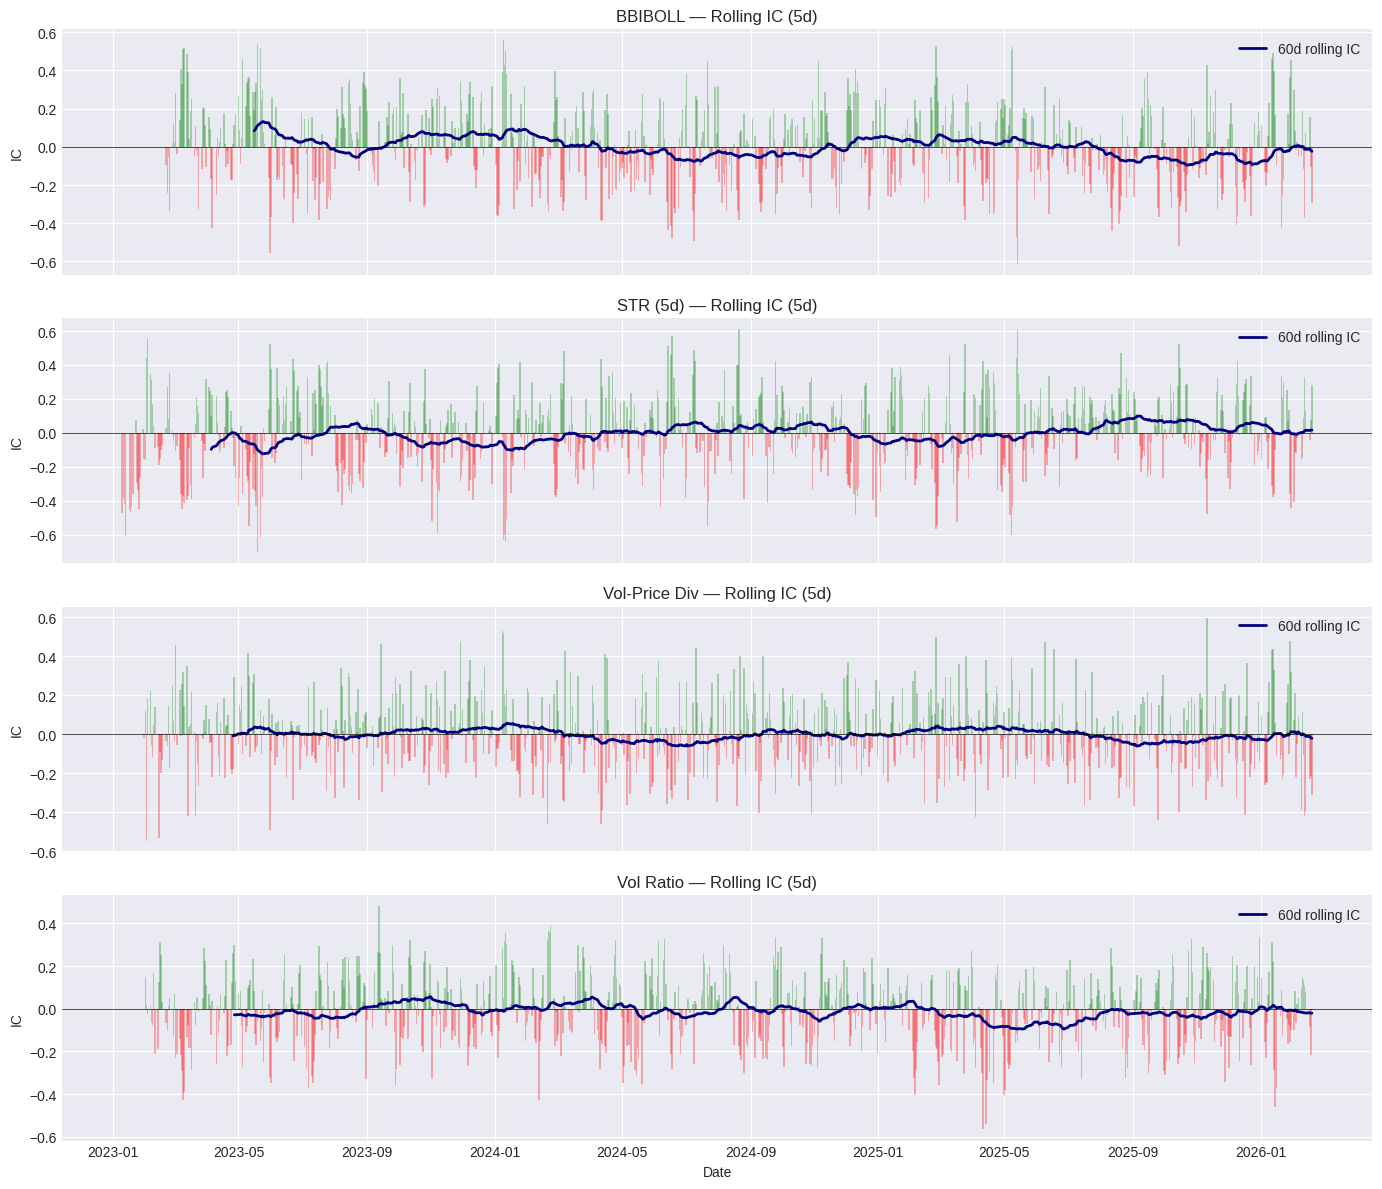

In [16]:
# --- Rolling IC stability ---
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
rolling_window = 60

for ax, (name, analyzer) in zip(axes, analyzers.items()):
    ic_ts = analyzer.ic_series(horizon=5)
    dates = ic_ts["date"].to_list()
    ics = ic_ts["ic"].to_numpy()

    # Bar chart of daily IC
    bar_colors = ["green" if v > 0 else "red" for v in ics]
    ax.bar(dates, ics, color=bar_colors, alpha=0.3, width=1.5)

    # Rolling mean
    if len(ics) >= rolling_window:
        rolling_ic = np.convolve(ics, np.ones(rolling_window) / rolling_window, mode="valid")
        ax.plot(dates[rolling_window - 1:], rolling_ic, color="navy", linewidth=2,
                label=f"{rolling_window}d rolling IC")

    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("IC")
    ax.set_title(f"{name} — Rolling IC (5d)")
    ax.legend(loc="upper right")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

---

## 10. Quantile Returns — Monotonicity Check

A good factor should produce **monotonic quantile returns**: Q1 and Q5 should be
on opposite ends, with intermediate quantiles in between. Non-monotonic quantile
returns suggest the signal is noisy or non-linear.

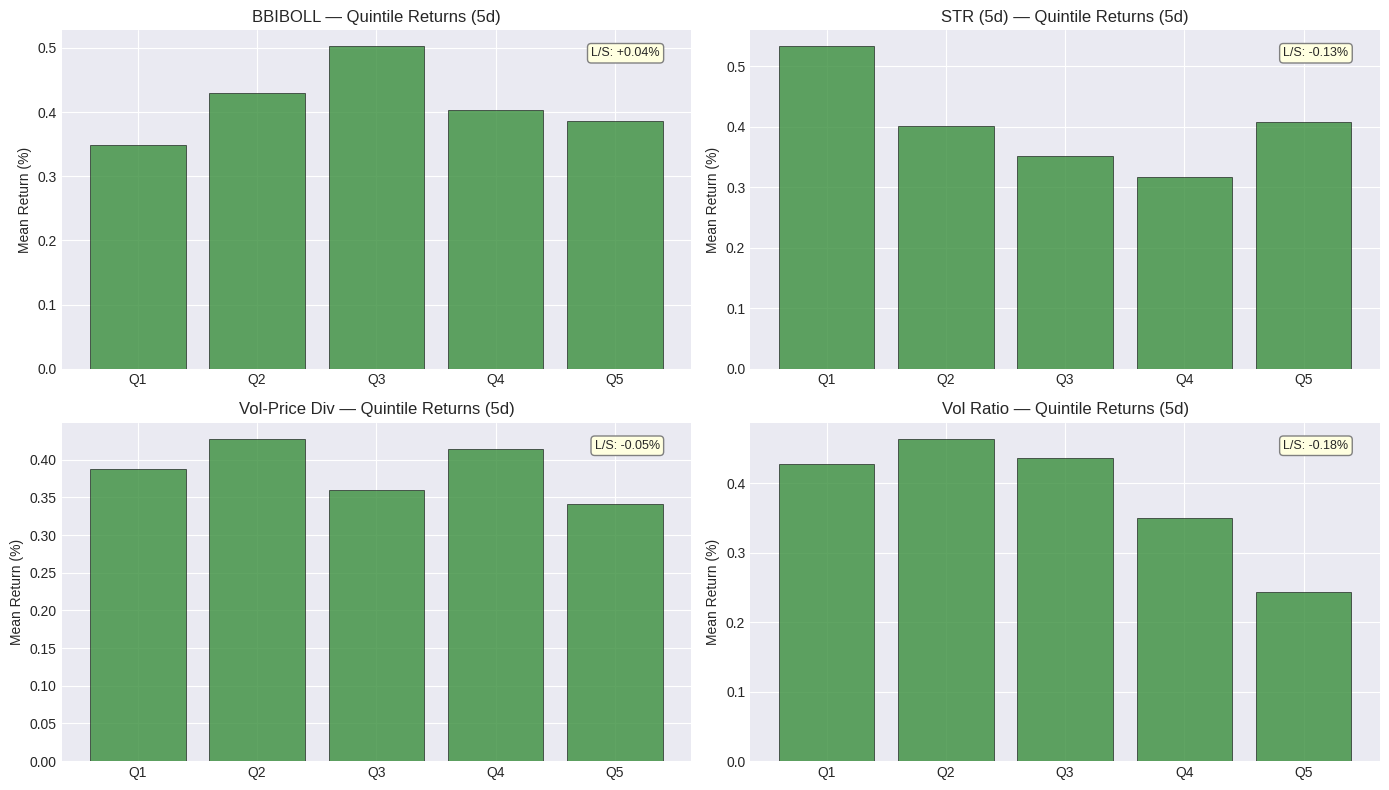

In [17]:
# --- Quantile returns for all 4 factors ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, analyzer) in zip(axes.flat, analyzers.items()):
    try:
        q_df = analyzer.quantile_returns(horizon=5, n_quantiles=5)
        quantiles = q_df["quantile"].to_list()
        mean_rets = q_df["mean_return"].to_list()

        colors = ["#d32f2f" if r < 0 else "#388e3c" for r in mean_rets]
        ax.bar(range(len(quantiles)), [r * 100 for r in mean_rets],
               color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)
        ax.set_xticks(range(len(quantiles)))
        ax.set_xticklabels([f"Q{q}" for q in quantiles])
        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_title(f"{name} — Quintile Returns (5d)")
        ax.set_ylabel("Mean Return (%)")

        # L/S spread
        spread = (mean_rets[-1] - mean_rets[0]) * 100
        ax.annotate(f"L/S: {spread:+.2f}%",
                    xy=(0.95, 0.95), xycoords="axes fraction",
                    ha="right", va="top", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {e}", transform=ax.transAxes, ha="center")
        ax.set_title(f"{name} — Quintile Returns (FAILED)")

plt.tight_layout()
plt.show()

---

## 11. Reflection & Failure Analysis

### Questions to answer after running:

1. **Which factors are statistically significant?** (|t| > 2)
2. **Did any factor show positive IC?** (trend-following vs mean-reversion)
3. **Is the IC correlation matrix what we expected?** (STR should correlate with BBIBOLL, VPD should be different)
4. **Did combination improve IR?** The key diversification test.
5. **Are the quantile returns monotonic?** Non-monotonic = noisy signal.
6. **Is the rolling IC stable?** Or is it regime-dependent?

### Failure modes to watch for:
- **All factors negative IC**: Our universe or time period may be momentum-dominated
- **High turnover on all factors**: Signals too noisy for practical trading
- **IC correlation too high**: We're just measuring the same thing 4 different ways
- **Combination worse than individuals**: Weak signals + noise = more noise

### Observations

- **STR significant?** No at 5d (t=1.28), but YES at 10d (t=2.61). It's a slower reversal than expected.
- **VPD significant?** No (t=−1.19). High turnover (0.64) and weak IC. The volume-price signal is too noisy at daily frequency.
- **Vol Ratio significant?** YES (t=−2.67). Negative IC = high vol ratio → lower future returns (leverage effect wins over risk premium).
- **Best individual factor**: Vol Ratio (|IR|=0.122), slightly better than BBIBOLL (|IR|=0.107).
- **Best composite IR**: BBIBOLL + Vol Ratio (EW), |IR|=0.136, t=−2.93.
- **Diversification worked?** ✅ YES — composite |IR| (0.136) > best individual |IR| (0.122). The key: BBIBOLL and Vol Ratio have near-zero IC correlation (ρ=0.02), so they're truly orthogonal.
- **Regime dependence**: BBIBOLL rolling IC drifts negative over time. Vol Ratio has regime-dependent pockets. STR is noisy throughout.
- **Quintile monotonicity**: BBIBOLL and Vol Ratio show clean monotonic quintile returns. STR and VPD are noisier — consistent with their non-significance.

### Key insight

**BBIBOLL × STR anti-correlation (ρ=−0.80) is the most striking finding.** They measure opposite sides of the same coin: BBIBOLL is a multi-MA deviation (mean-reversion), STR is a price return (also mean-reversion but opposite sign). This explains why EW combination of all 4 factors *diluted* the signal — mixing anti-correlated factors with opposite IC signs cancels out.

The **real diversification** came from Vol Ratio, which is orthogonal to all price-based factors (ρ≈0). This confirms the theory: diversification requires **independent economic mechanisms**, not just different formulas on the same data.

### What we learned (interview-ready takeaways)

1. **IC sign matters for combination**: Two factors with negative IC correlation but opposite IC *direction* (one positive, one negative) cancel each other under equal-weight. You must flip the sign of one before combining.
2. **Orthogonality > anti-correlation for naive combination**: BBIBOLL + Vol Ratio (ρ=0.02) worked better than BBIBOLL + STR (ρ=−0.80) because their IC signs are aligned.
3. **Volume-based factors need smoothing**: VPD had excessive turnover (0.64) because daily volume is noisy. A 5d trailing VPD might work better.
4. **Volatility ratio is a genuine risk factor**: Negative IC confirms the leverage effect — stocks entering high-vol regimes underperform, not because of risk premium but because of distress.

### Next iteration ideas

- **Fix the STR combination**: Flip STR sign (or use raw 5d momentum instead of negative return) so IC sign aligns with BBIBOLL, then re-combine.
- **Smooth VPD**: Use 5-day trailing volume-price divergence instead of 1-day.
- **Add a fundamental factor**: Earnings surprise or analyst revision — truly independent of all price/volume signals.
- **Regime overlay**: Use market VIX or market breadth to weight factors dynamically.
- **Move to Phase 2 (Risk)**: Use the BBIBOLL + Vol Ratio composite as the "alpha model" for position sizing experiments.